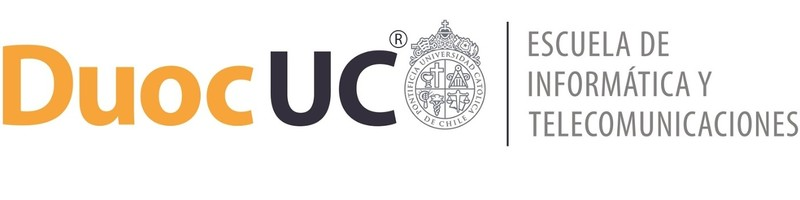

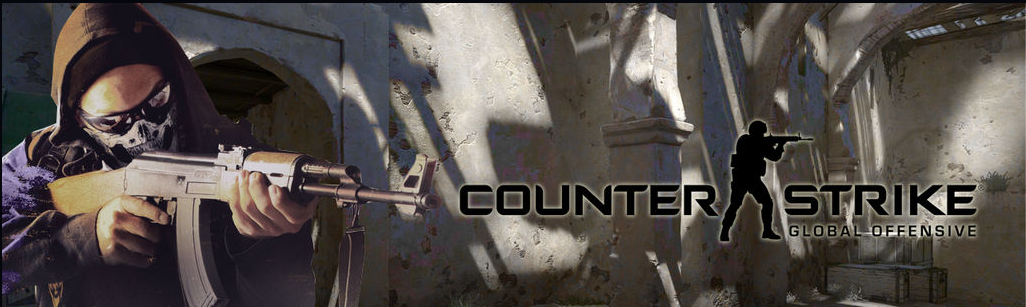

# Informe Técnico - Examen Transversal: Caso Counter Strike


Integrantes:

*Anderson Tineo
*Cristobal Rozas

Docente:     
FELIPE RODRIGO ORDENES GACITUA
Sección: MLY0100 -001D

# Caso Fundamentos de Machine Learning

CONTEXTO CASO

Valve, los ha contactado como equipo de análisis de datos y modelado de Machine Learning para analizar y realizar modelos predictivos sobre los datos.

En cada partida de Counter Strike: GO dos equipos de 5 jugadores (denominados terroristas y contra-terroristas) se enfrentan.


El objetivo del equipo terrorista es plantar una bomba con timer de 45 segundos en uno de dos sitios específicos dentro de un mapa. Por otro lado, el objetivo del equipo contra-terrorista es evitar que la bomba sea plantada o desactivarla antes de que esta explote cuando ya ha sido plantada. Los datos a utilizar corresponden a sobre 7000 partidas del juego (con un máximo de 10 jugadores c/u)  


Los datos han sido extraídos de replays, los cuales son archivos propietarios con la información de cada una de las acciones realizadas por cada jugador dentro de una partida. Los replays han sido extraídos de la red utilizando un scrapper y pre-procesados utilizando un script.  



En este caso, la data corresponde a un archivo CSV con 79.157 filas, cada una correspondiente a un jugador dentro de una partida. El archivo contiene 29 columnas correspondientes a variables que describen las acciones del jugador dentro del juego.


$$
\begin{aligned}
&\begin{array}{cccc}
\hline \hline \text { Dato } & \text { Descripción } \\
\hline Map & \text {Nombre  del Mapa donde se jugó la partida}  \\
\hline \text{ Team} & \text { Nombre de equipo al que pertenece el jugador} \\
\hline \text{ InternalTeamId} & \text { Identificador del equipo al que pertenece el jugador.} \\
\hline \text{ MatchId} & \text { Identificador de la partida.} \\
\hline \text{ RoundId} & \text { Identificador de la ronda (los equipos se enfrentan en rondas de 5 partidas seguidas)} \\
\hline \text{ MatchWinner} & \text { Indica si el jugador ganó o no la partida.} \\
\hline \text{ RoundWinner} & \text { Indica si el jugador ganó o no la ronda analizada.} \\
\hline \text{ Survived} & \text { Indica si el jugador sobrevivió o no a la partida (sobrevivir no es sinónimo de ganar).} \\
\hline \text{ AbnormalMatch} & \text { Indica si la partida del jugador tuvo un error por conexión de red} \\
\hline \text{ TimeAlive} & \text { Indica el tiempo en segundos que el jugador estuvo vivo durante el juego} \\
\hline \text{ TravelledDistance} & \text { Distancia viajada por el jugador durante la partida.} \\
\hline \text{ RLethalGrenadesThrown/RNonLethalGrenadesThrown} & \text { Cantidad de granadas lanzadas, categorizadas en letales y no-letales.} \\
\hline \text{ PrimaryXXXX} & \text { Porcentaje de uso arma clasificada como primaria. Categorizada en AssaultRifle, SniperRifle, SMG, Heavy y Pistol.} \\
\hline \text{ [Match|Round] Assists} & \text { Cantidad de asistencias efectuadas por el jugador durante la partida o la ronda.} \\
\hline \text{ [Match|Round] Kills} & \text { Cantidad de kills efectuados por el jugador durante la partida o la ronda.} \\
\hline \text{ [Match|Round] FlankKills} & \text { Cantidad de kills efectuados por el jugador sin que la víctima lo viese durante la partida o la ronda.} \\
\hline \text{ [Match|Round] HeadShots} & \text { Cantidad de kills efectuados por el jugador a través de un tiro en la cabeza durante la partida o la ronda.} \\
\hline \text{ RoundStartingEquipmentValue} & \text { Valor del equipamiento llevado por el jugador al inicio de la ronda.} \\
\hline \text{ TeamStartingEquipmentValue} & \text { Valor promedio del equipamiento llevado por el equipo del jugador al inicio de la ronda.} \\
\end{array}
\end{aligned}
$$

## Fase 1: Business Understanding

In [ ]:
# Insertar cuantos bloques de código y markdown consideren necesarios

# Se recomienda investigar sobre el contexto de negocio, sobre los datos, uso de
# los campos en estadísticas de juegos, ver en qué se relacionan los contenidos
# revisados en la asignatura con lo planteado como caso de estudio.
# Plantear hipótesis del negocio posibles para objetivos de tareas de regresión y de clasificación

from google.colab import files
import pandas as pd
import pandas as pd
import numpy as np
import seaborn as sb


# Subir el archivo
uploaded = files.upload()
for fn in uploaded.keys():
    name = fn

# Intentar cargar el archivo con el delimitador correcto
try:
    df = pd.read_csv(name, delimiter=';')
    print("Archivo cargado correctamente con el delimitador ';'.")
except:
    print("Error al cargar el archivo con el delimitador ';'. Intenta con otro delimitador.")

# Mostrar las primeras filas del dataframe para verificar la carga
print(df.head())
print(df.info())


#Contexto de Negocio

El análisis se centra en las estadísticas de un videojuego competitivo. Los datos incluyen varias métricas de rendimiento de los jugadores y los equipos durante las rondas de juego. Por ejemplo, los datos podrían ser eliminaciones por ronda matando a un jugador del enemigo, tiempo de vida vivido hasta la ronda, distancia recorrida, valor del equipo al principio de la ronda y si el equipo ganó la ronda.

Uso de Campos

- RoundKills: muestra los asesinatos hechos por el jugador en la ronda determinada. Es una de las métricas clave para determinar la agresividad y productividad del jugador.
- TimeAlive: el tiempo vivo es una función entre un jugador permanecer vivo durante una ronda. Así, el tiempo representa la capacidad de sobrevivencia del jugador y la táctica defensiva.

- TravelledDistance: indica el porcentaje de movimiento de un jugador en una ronda. Esta variable también podría considerarse en función de la estrategia de movimiento y ubicación en el mapa.

- RoundStartingEquipmentValue: indica el valor del equipo inicial de un jugador o equipo. En cierta forma, esto influirá en el rendimiento de una ronda.

- RoundWinner: esta es una función entre un jugador, lo que implica si el equipo del jugador ganó la ronda. Por lo tanto, esta variable es importante para evaluar la efectividad del equipo y la estrategia.

- MatchWinner: similar al anterior, pero a nivel de un juego completo.


#Relacionado con los Contenidos Revisados en la Asignatura

En una asignatura centrada en la ciencia de los datos y aprendizaje automático, los conceptos clave involucran la limpieza de datos, así como el análisis exploratorio de datos (EDA), el modelado predictivo, la validación de modelos y la interpretación de resultados. Esta tarea relaciona este caso con esos contenidos al crear la oportunidad perfecta para aprovechar las técnicas de regresión y clasificación para predecir antes y durante un partido, y luego, analizar los resultados de la ronda y partido previos.

Negocio Hipótesis formulation


**Predicción de Asesinatos por Partido (MatchKills):**

- Hipotesis: el valor de equipamiento al comienzo de la ronda, asesinatos por ronda, y tiempo vivo no tienen ningún impacto significativo en el número total de recuentos de asesinato en un partido.
- Variables: RoundStartingEquipmentValue, RoundKills, TimeAlive, TravelledDistance.

**Predicción del tiempo vivo :**
- Hipótesis: los jugadores con un valor de equipo inicial más alto y más asesinatos / asistencias tendrán más probabilidades de sobrevivir.
- Variables: RoundStartingEquipmentValue, Round Assists, RoundKills.

**Objetivos para la tarea de clasificación**
Clasificación del ganador de ronda :
- Hipótesis: los equipos con un valor de equipo inicial más alto y más asesinatos tendrán una mayor probabilidad de ganar la ronda.
- Variables: RoundStartingEquipmentValue, RoundKills, RoundAssists, RoundHeadshots.

In [ ]:
# Display the first few rows of the dataframe
df.head()

,Unnamed: 0,Map,Team,InternalTeamId,MatchId,RoundId,RoundWinner,MatchWinner,Survived,AbnormalMatch,...,RoundKills,RoundAssists,RoundHeadshots,RoundFlankKills,RoundStartingEquipmentValue,TeamStartingEquipmentValue,MatchKills,MatchFlankKills,MatchAssists,MatchHeadshots
0,600,de_inferno,Terrorist,1,4,1,False,True,False,False,...,0,0,0,0,750,4400,0,0,0,0
1,601,de_inferno,Terrorist,1,4,1,False,True,False,False,...,0,0,0,0,800,4400,0,0,0,0
2,602,de_inferno,Terrorist,1,4,1,False,True,False,False,...,0,0,0,0,1000,4400,0,0,0,0
3,603,de_inferno,Terrorist,1,4,1,False,True,False,False,...,0,0,0,0,850,4400,0,0,0,0
4,604,de_inferno,Terrorist,1,4,1,False,True,True,False,...,0,0,0,0,1000,4400,0,0,0,0


In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,79157.0,60570.193640,36436.598386,600.0,30830.0,56720.0,90639.0,123779.0
InternalTeamId,79157.0,1.500006,0.500003,1.0,1.0,2.0,2.0,2.0
MatchId,79157.0,250.525033,149.557804,4.0,128.0,236.0,373.0,511.0
RoundId,79157.0,12.765517,7.432837,1.0,6.0,12.0,19.0,36.0
RLethalGrenadesThrown,79157.0,0.498667,0.597985,0.0,0.0,0.0,1.0,4.0
RNonLethalGrenadesThrown,79157.0,1.258057,1.184909,0.0,0.0,1.0,2.0,6.0
PrimaryAssaultRifle,79157.0,0.675363,0.464125,0.0,0.0,1.0,1.0,1.0
PrimarySniperRifle,79157.0,0.089840,0.279797,0.0,0.0,0.0,0.0,1.0
PrimaryHeavy,79157.0,0.005964,0.075497,0.0,0.0,0.0,0.0,1.0
PrimarySMG,79157.0,0.007046,0.082453,0.0,0.0,0.0,0.0,1.0


#Análisis Exploratorio de Datos

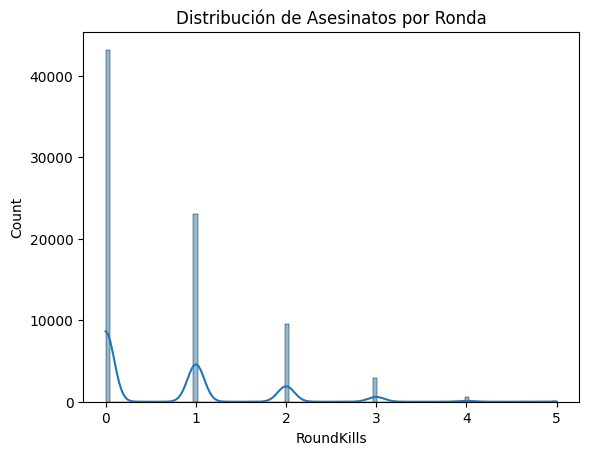

<ipython-input-4-7b4b63aaf074>:11: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='RoundWinner', y='RoundStartingEquipmentValue', data=df, ci=None, capsize=.2)


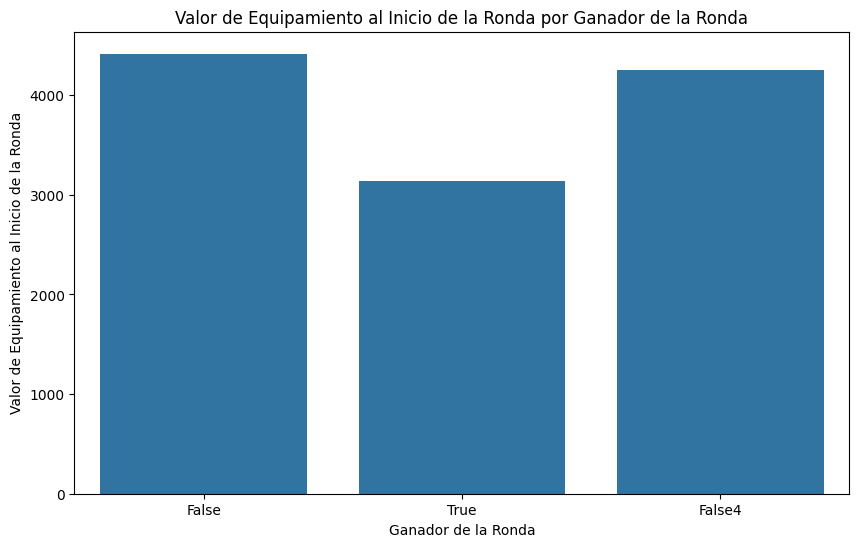

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualizar las distribuciones de algunas variables clave
sns.histplot(df['RoundKills'], kde=True)
plt.title('Distribución de Asesinatos por Ronda')
plt.show()


plt.figure(figsize=(10, 6))
sns.barplot(x='RoundWinner', y='RoundStartingEquipmentValue', data=df, ci=None, capsize=.2)
plt.title('Valor de Equipamiento al Inicio de la Ronda por Ganador de la Ronda')
plt.xlabel('Ganador de la Ronda')
plt.ylabel('Valor de Equipamiento al Inicio de la Ronda')
plt.show()




## Fase 2: Data Understanding

In [ ]:
# Insertar cuantos bloques de código consideren necesarios

# Se recomienda obtener estadísticos descriptivos para apoyar hipótesis inferenciales.
# Reconocer la naturaleza de los datos y como tratarlos en etapas posteriores y dar ideas de como se podría transformar.
# Identificar MissingValues, outliers, medidas de posición, medidas de dispersión etc.

In [ ]:
# Obtener estadísticas descriptivas
print(df.describe())

          Unnamed: 0  InternalTeamId       MatchId       RoundId  \
count   79157.000000    79157.000000  79157.000000  79157.000000   
mean    60570.193640        1.500006    250.525033     12.765517   
std     36436.598386        0.500003    149.557804      7.432837   
min       600.000000        1.000000      4.000000      1.000000   
25%     30830.000000        1.000000    128.000000      6.000000   
50%     56720.000000        2.000000    236.000000     12.000000   
75%     90639.000000        2.000000    373.000000     19.000000   
max    123779.000000        2.000000    511.000000     36.000000   

       RLethalGrenadesThrown  RNonLethalGrenadesThrown  PrimaryAssaultRifle  \
count           79157.000000              79157.000000         79157.000000   
mean                0.498667                  1.258057             0.675363   
std                 0.597985                  1.184909             0.464125   
min                 0.000000                  0.000000             0.00

 punto 2 :Reconocer la naturaleza de los datos y como tratarlos en etapas posteriores y dar ideas de como se podría transformar.

se pueden crear nuevas características combinando o transformando las existentes. Por ejemplo  se puede calcular la tasa de precisión de los disparos dividiendo RoundHeadshots entre RoundKills.

Valores faltantes por columna:
Unnamed: 0                     0
Map                            0
Team                           2
InternalTeamId                 0
MatchId                        0
RoundId                        0
RoundWinner                    0
MatchWinner                    1
Survived                       0
AbnormalMatch                  0
TimeAlive                      0
TravelledDistance              0
RLethalGrenadesThrown          0
RNonLethalGrenadesThrown       0
PrimaryAssaultRifle            0
PrimarySniperRifle             0
PrimaryHeavy                   0
PrimarySMG                     0
PrimaryPistol                  0
FirstKillTime                  0
RoundKills                     0
RoundAssists                   0
RoundHeadshots                 0
RoundFlankKills                0
RoundStartingEquipmentValue    0
TeamStartingEquipmentValue     0
MatchKills                     0
MatchFlankKills                0
MatchAssists                   0
MatchHeadsho

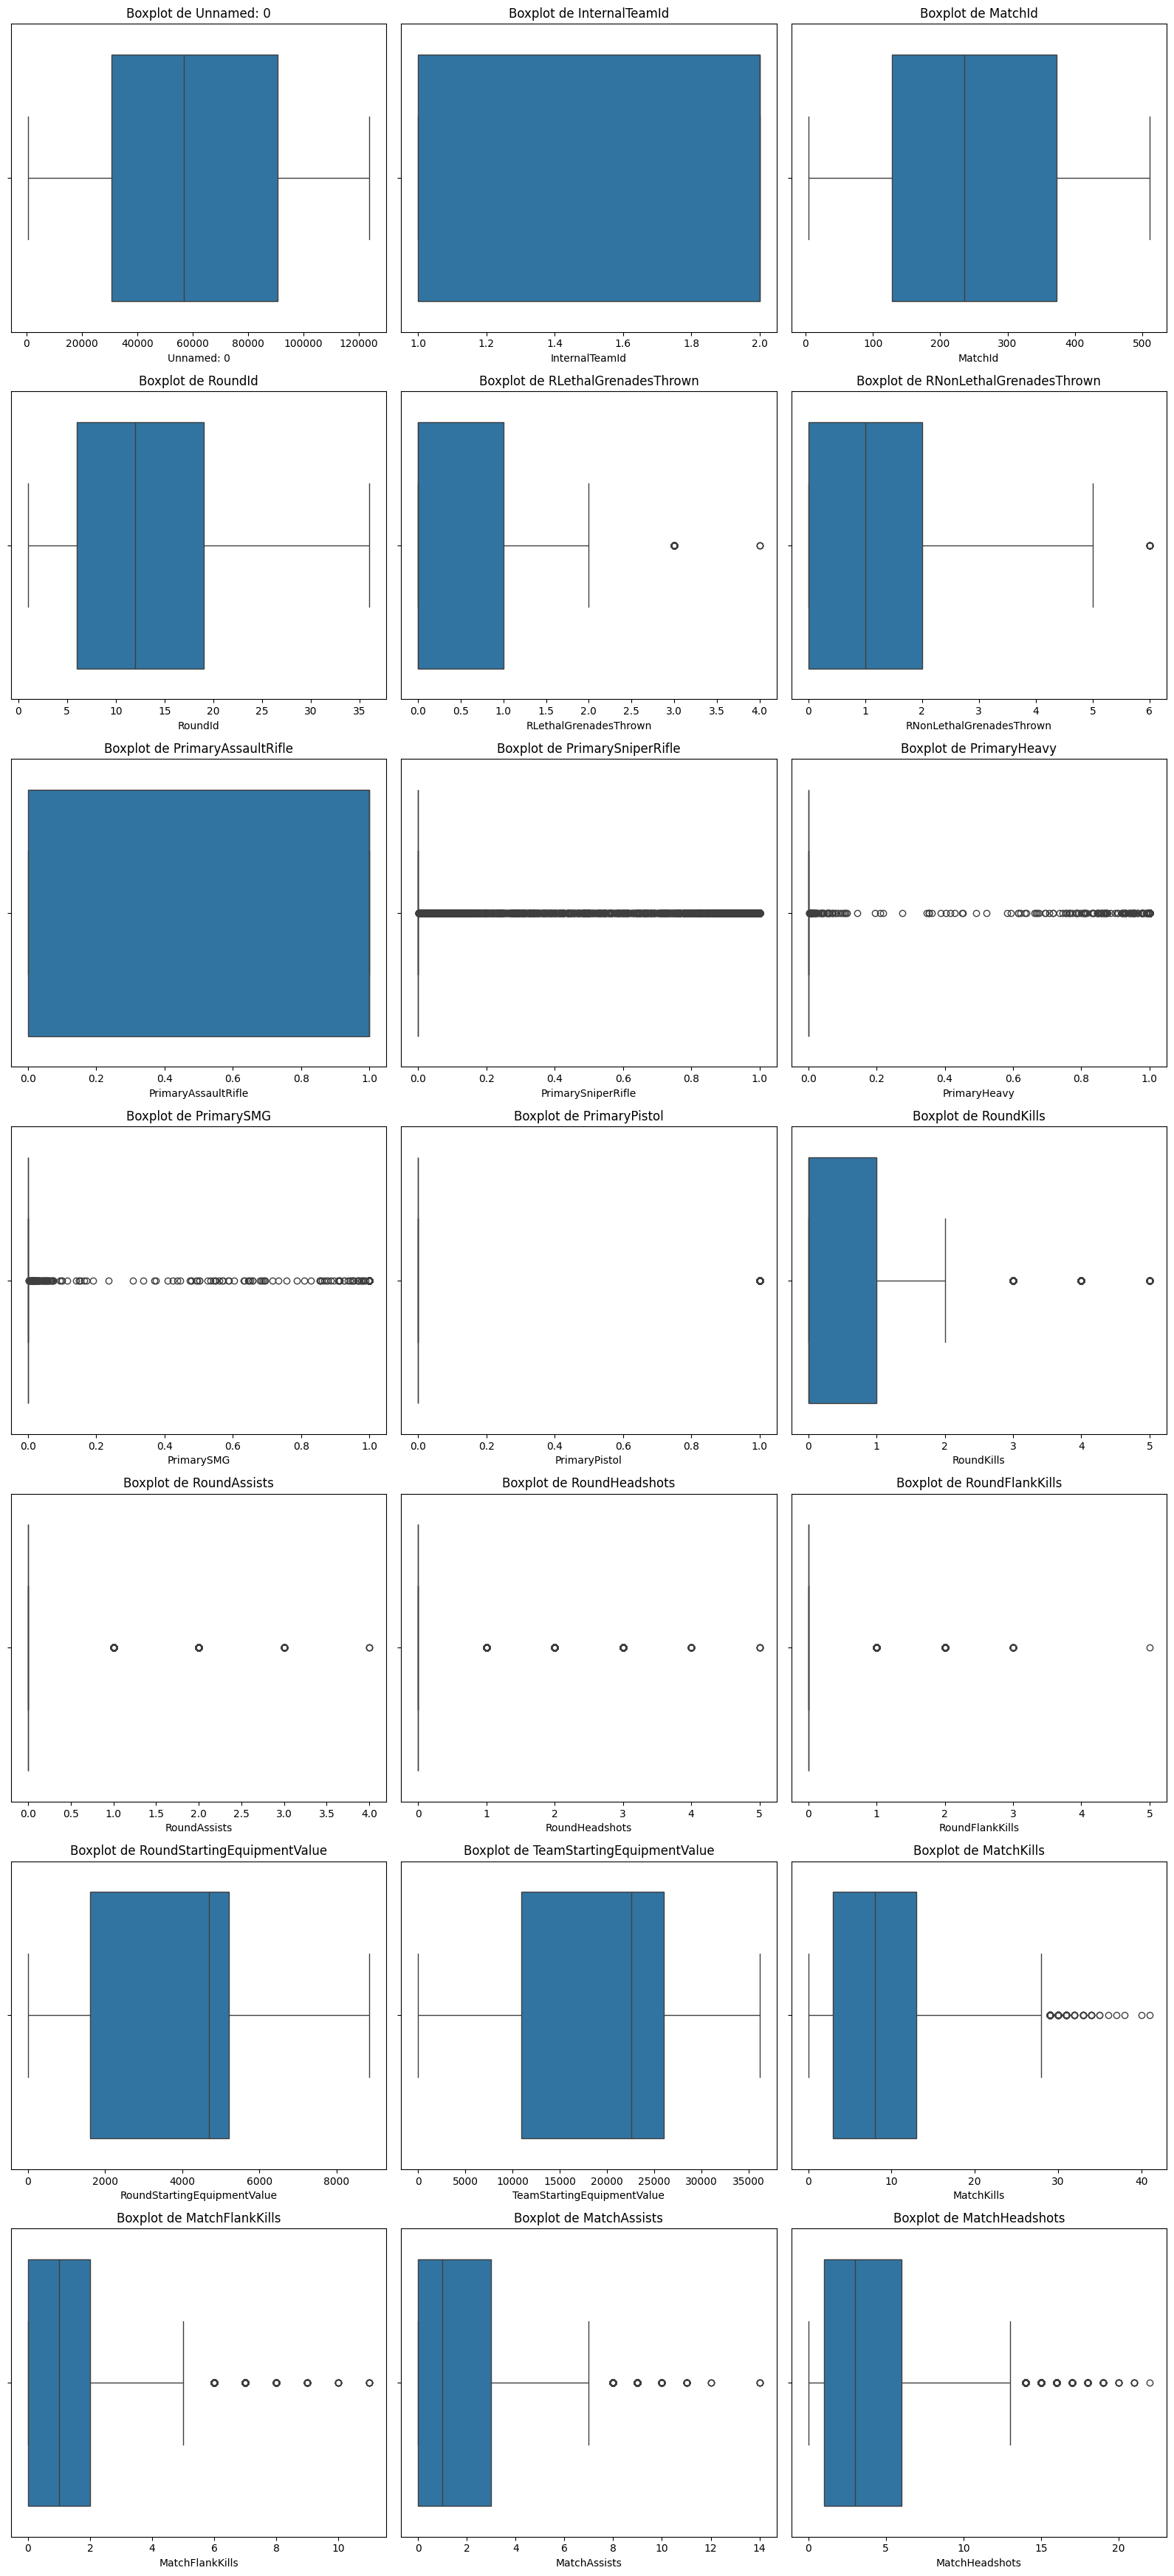

Media de RoundKills: 0.6713493437093372
Mediana de RoundKills: 0.0
Desviación estándar de RoundKills: 0.8817924537042205


In [ ]:
# Verificar si hay valores faltantes en el DataFrame
missing_values = df.isnull().sum()
print("Valores faltantes por columna:")
print(missing_values)

# Visualizar outliers
# Obtener columnas numéricas
numeric_columns = df.select_dtypes(include=np.number).columns

# Calcular el número de filas y columnas necesarias para acomodar los boxplots
num_plots = len(numeric_columns)
num_cols = 3  # Número de columnas en cada fila
num_rows = (num_plots - 1) // num_cols + 1  # Calcular el número de filas

# Visualizar boxplots para identificar outliers en todas las columnas numéricas
plt.figure(figsize=(16, 5*num_rows))
for i, column in enumerate(numeric_columns):
    plt.subplot(num_rows, num_cols, i + 1)
    sns.boxplot(x=df[column])
    plt.title(f'Boxplot de {column}')
    plt.tight_layout()
plt.show()

# Calcular medidas de posición y dispersión
print("Media de RoundKills:", np.mean(df['RoundKills']))
print("Mediana de RoundKills:", np.median(df['RoundKills']))
print("Desviación estándar de RoundKills:", np.std(df['RoundKills']))

## Fase 3: Data Preparatio:



In [ ]:
# Insertar cuantos bloques de código consideren necesarios

# Se recomienda considerar todas las transformaciones necesarias para obtener la data lo más limpia posible.
# Realizar tratamiento a todos los datos que consideren necesarios.

#volver a cargar la tabla

In [ ]:
import pandas as pd
from google.colab import files

# Subir el archivo CSV
uploaded = files.upload()

# Cargar el archivo CSV con manejo de errores adecuado
file_path = 'Anexo ET_demo_round_traces_2022.csv'
data = pd.read_csv(file_path, delimiter=',', on_bad_lines='skip')

# Mostrar los nombres de las columnas
print("Nombres de las columnas:")
print(data.columns)

# Mostrar las primeras filas del DataFrame para verificar que se ha cargado correctamente
print(data.head())

#Limpiar los datos eliminando filas con valores nulos

In [ ]:
# Eliminar filas con valores nulos en cualquier columna
data_cleaned = data.dropna()

# Mostrar la cantidad de filas antes y después de la limpieza
print(f"Filas originales: {data.shape[0]}")
print(f"Filas después de eliminar nulos: {data_cleaned.shape[0]}")

# Mostrar los primeros registros del dataframe limpio
print(data_cleaned.head())
print(data_cleaned.info())


Filas originales: 79155
Filas después de eliminar nulos: 79155
  ;Map;Team;InternalTeamId;MatchId;RoundId;RoundWinner;MatchWinner;Survived;AbnormalMatch;TimeAlive;TravelledDistance;RLethalGrenadesThrown;RNonLethalGrenadesThrown;PrimaryAssaultRifle;PrimarySniperRifle;PrimaryHeavy;PrimarySMG;PrimaryPistol;FirstKillTime;RoundKills;RoundAssists;RoundHeadshots;RoundFlankKills;RoundStartingEquipmentValue;TeamStartingEquipmentValue;MatchKills;MatchFlankKills;MatchAssists;MatchHeadshots
0  600;de_inferno;Terrorist;1;4;1;False;True;Fals...                                                                                                                                                                                                                                                                                                                                                                                
1  601;de_inferno;Terrorist;1;4;1;False;True;Fals...                                           

#Eliminar columnas no relevantes (si hay alguna)

In [ ]:
# Asignar el DataFrame original a data_cleaned
data_cleaned = df.copy()

# Eliminar columnas irrelevantes
if 'Unnamed: 0' in data_cleaned.columns:
    data_cleaned = data_cleaned.drop(columns=['Unnamed: 0'])

# Mostrar los primeros registros del dataframe limpio
print(data_cleaned.head())
print(data_cleaned.info())


          Map       Team  InternalTeamId  MatchId  RoundId RoundWinner  \
0  de_inferno  Terrorist               1        4        1       False   
1  de_inferno  Terrorist               1        4        1       False   
2  de_inferno  Terrorist               1        4        1       False   
3  de_inferno  Terrorist               1        4        1       False   
4  de_inferno  Terrorist               1        4        1       False   

  MatchWinner  Survived  AbnormalMatch               TimeAlive  ...  \
0        True     False          False  51.120.248.995.704.500  ...   
1        True     False          False   4.348.662.552.266.170  ...   
2        True     False          False   3.735.469.847.054.540  ...   
3        True     False          False   4.767.886.136.441.470  ...   
4        True      True          False   5.312.251.089.027.310  ...   

  RoundKills  RoundAssists  RoundHeadshots  RoundFlankKills  \
0          0             0               0                0   
1 

## Fase 4: Modeling

### Regresión

Saving Anexo ET_demo_round_traces_2022.csv to Anexo ET_demo_round_traces_2022 (1).csv


<ipython-input-5-61d3485cb05c>:23: DtypeWarning: Columns (6,7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(name, delimiter=';')


Archivo cargado correctamente con el delimitador ';'.
   Unnamed: 0         Map       Team  InternalTeamId  MatchId  RoundId  \
0         600  de_inferno  Terrorist               1        4        1   
1         601  de_inferno  Terrorist               1        4        1   
2         602  de_inferno  Terrorist               1        4        1   
3         603  de_inferno  Terrorist               1        4        1   
4         604  de_inferno  Terrorist               1        4        1   

  RoundWinner MatchWinner  Survived  AbnormalMatch  ... RoundKills  \
0       False        True     False          False  ...          0   
1       False        True     False          False  ...          0   
2       False        True     False          False  ...          0   
3       False        True     False          False  ...          0   
4       False        True      True          False  ...          0   

  RoundAssists  RoundHeadshots  RoundFlankKills  RoundStartingEquipmentValue  \


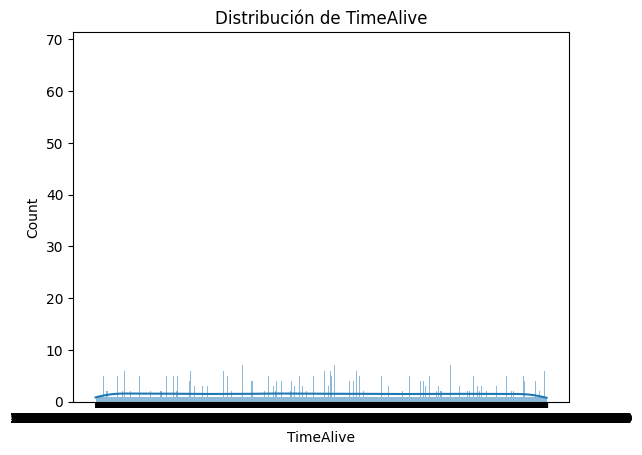

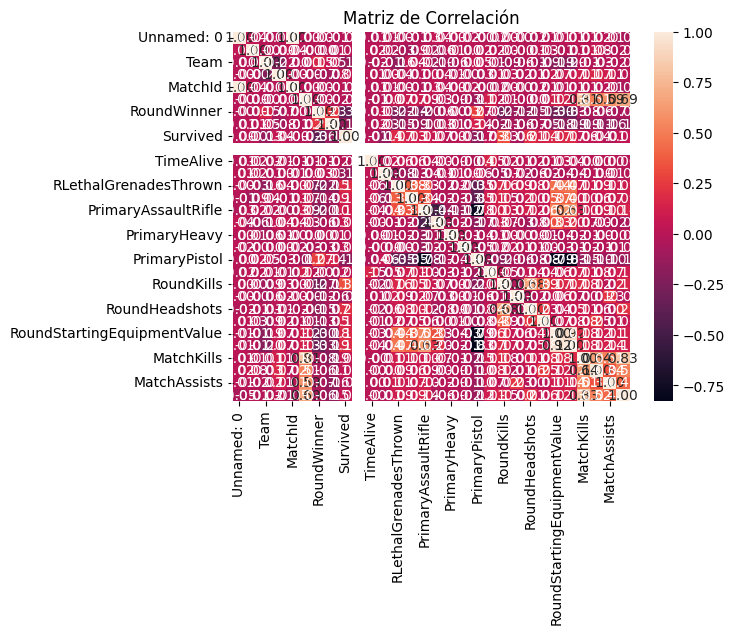

Mean Squared Error: 0.9928390444718105
R^2 Score: 0.0008821428116283503


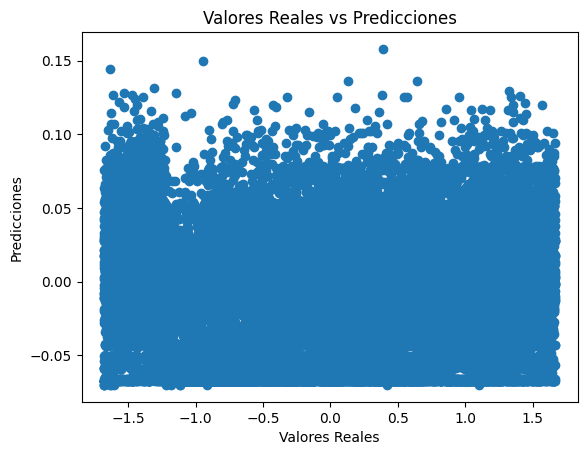

Best Model Mean Squared Error: 0.9898578521906001
Best Model R^2 Score: 0.003882188448888657


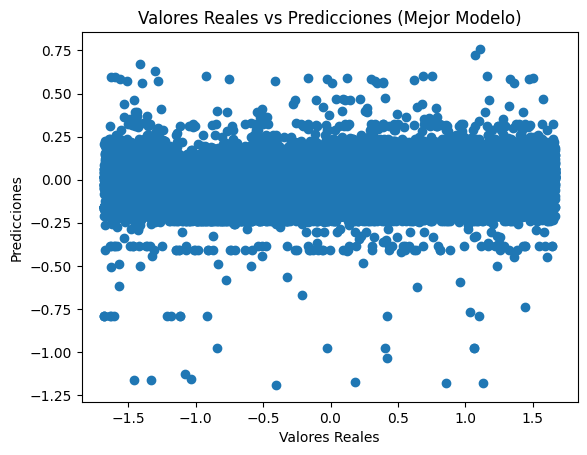

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Realizar tarea de regresión de datos orientado al caso entregado

# Importar las librerías necesarias
from google.colab import files
import pandas as pd
import numpy as np
import joblib
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression

# Subir el archivo
uploaded = files.upload()
for fn in uploaded.keys():
    name = fn

# Intentar cargar el archivo con el delimitador correcto
try:
    df = pd.read_csv(name, delimiter=';')
    print("Archivo cargado correctamente con el delimitador ';'.")
except:
    print("Error al cargar el archivo con el delimitador ';'. Intenta con otro delimitador.")
    # Intentar cargar con otro delimitador (ejemplo ',')
    try:
        df = pd.read_csv(name, delimiter=',')
        print("Archivo cargado correctamente con el delimitador ','.")
    except:
        print("Error al cargar el archivo con el delimitador ','. Revisa el archivo y el delimitador.")

# Exploración inicial de los datos
print(df.head())
print(df.info())
print(df.describe())

# Verificar la distribución de TimeAlive
sns.histplot(df['TimeAlive'], kde=True)
plt.title('Distribución de TimeAlive')
plt.show()

# Preprocesamiento de datos
# Imputar valores faltantes si es necesario
df.fillna(method='ffill', inplace=True)

# Codificación de variables categóricas
categorical_columns = df.select_dtypes(include=['object', 'category']).columns
label_encoders = {}

# Convertir todas las columnas categóricas a strings para asegurar uniformidad
for col in categorical_columns:
    df[col] = df[col].astype(str)
    if df[col].isnull().any():
        df[col] = df[col].fillna('missing')
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

# Normalización/Estandarización de variables numéricas
scaler = StandardScaler()
numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns
df[numerical_columns] = scaler.fit_transform(df[numerical_columns])

# Comprobar correlaciones con las variables numéricas transformadas
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, fmt=".2f")
plt.title('Matriz de Correlación')
plt.show()

# Selección de características y variable objetivo
# Ajustar la selección de características según el análisis de correlación
X = df[['RoundStartingEquipmentValue', 'RoundAssists', 'RoundKills']]
y = df['TimeAlive']

# División de los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Entrenamiento del modelo de regresión (Regresión Lineal en este caso)
model = LinearRegression()
model.fit(X_train, y_train)

# Predicciones
y_pred = model.predict(X_test)

# Evaluación del modelo
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R^2 Score:", r2)

# Visualización de resultados
plt.scatter(y_test, y_pred)
plt.xlabel('Valores Reales')
plt.ylabel('Predicciones')
plt.title('Valores Reales vs Predicciones')
plt.show()

# Optimización del modelo mediante Grid Search (ejemplo con Random Forest Regressor)
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10]
}
grid_search = GridSearchCV(RandomForestRegressor(random_state=42), param_grid, cv=5, scoring='neg_mean_squared_error')
grid_search.fit(X_train, y_train)

# Evaluar el mejor modelo
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test)

mse_best = mean_squared_error(y_test, y_pred_best)
r2_best = r2_score(y_test, y_pred_best)

print("Best Model Mean Squared Error:", mse_best)
print("Best Model R^2 Score:", r2_best)

# Visualización de resultados del mejor modelo
plt.scatter(y_test, y_pred_best)
plt.xlabel('Valores Reales')
plt.ylabel('Predicciones')
plt.title('Valores Reales vs Predicciones (Mejor Modelo)')
plt.show()

import joblib

joblib.dump(best_model, 'best_model.pkl')

# Descargar el archivo pickle a tu máquina local
from google.colab import files
files.download('best_model.pkl')



### Clasificación



In [ ]:
# Insertar cuantos bloques de código consideren necesarios

# Realizar tarea de clasificación de datos orientado al caso entregado

In [ ]:
from google.colab import files
import pandas as pd
import numpy as np
import joblib
import seaborn as sb
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score
from sklearn.ensemble import RandomForestClassifier

# Subir el archivo
uploaded = files.upload()
for fn in uploaded.keys():
    name = fn

# Intentar cargar el archivo con el delimitador correcto
try:
    df = pd.read_csv(name, delimiter=';')
    print("Archivo cargado correctamente con el delimitador ';'.")
except:
    print("Error al cargar el archivo con el delimitador ';'. Intenta con otro delimitador.")
    # Intentar cargar con otro delimitador (ejemplo ',')
    try:
        df = pd.read_csv(name, delimiter=',')
        print("Archivo cargado correctamente con el delimitador ','.")
    except:
        print("Error al cargar el archivo con el delimitador ','. Revisa el archivo y el delimitador.")

# Exploración inicial de los datos
print(df.head())
print(df.info())
print(df.describe())

# Preprocesamiento de datos
# Imputar valores faltantes si es necesario
df.fillna(method='ffill', inplace=True)

# Codificación de variables categóricas
label_encoders = {}
categorical_columns = df.select_dtypes(include=['object', 'category']).columns

# Convertir todas las columnas categóricas a strings para asegurar uniformidad
for col in categorical_columns:
    df[col] = df[col].astype(str)
    if df[col].isnull().any():
        df[col] = df[col].fillna('missing')
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

# Normalización/Estandarización de variables numéricas
scaler = StandardScaler()
numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns
df[numerical_columns] = scaler.fit_transform(df[numerical_columns])

# Selección de características y variable objetivo
X = df.drop('MatchWinner', axis=1)
y = df['MatchWinner']

# División de los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Entrenamiento del modelo de clasificación (Random Forest en este caso)
clf = RandomForestClassifier(random_state=42)
clf.fit(X_train, y_train)

# Predicciones
y_pred = clf.predict(X_test)
y_pred_proba = clf.predict_proba(X_test)[:, 1]

# Evaluación del modelo
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))
print("ROC AUC Score:", roc_auc_score(y_test, y_pred_proba))

# Optimización del modelo mediante Grid Search
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10]
}
grid_search = GridSearchCV(clf, param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)

# Evaluar el mejor modelo
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test)
y_pred_best_proba = best_model.predict_proba(X_test)[:, 1]

print("Best Model Accuracy:", accuracy_score(y_test, y_pred_best))
print("Best Model Confusion Matrix:\n", confusion_matrix(y_test, y_pred_best))
print("Best Model Classification Report:\n", classification_report(y_test, y_pred_best))
print("Best Model ROC AUC Score:", roc_auc_score(y_test, y_pred_best_proba))







Saving Anexo ET_demo_round_traces_2022.csv to Anexo ET_demo_round_traces_2022.csv


<ipython-input-4-df0ba49f0f32>:18: DtypeWarning: Columns (6,7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(name, delimiter=';')


Archivo cargado correctamente con el delimitador ';'.
   Unnamed: 0         Map       Team  InternalTeamId  MatchId  RoundId  \
0         600  de_inferno  Terrorist               1        4        1   
1         601  de_inferno  Terrorist               1        4        1   
2         602  de_inferno  Terrorist               1        4        1   
3         603  de_inferno  Terrorist               1        4        1   
4         604  de_inferno  Terrorist               1        4        1   

  RoundWinner MatchWinner  Survived  AbnormalMatch  ... RoundKills  \
0       False        True     False          False  ...          0   
1       False        True     False          False  ...          0   
2       False        True     False          False  ...          0   
3       False        True     False          False  ...          0   
4       False        True      True          False  ...          0   

  RoundAssists  RoundHeadshots  RoundFlankKills  RoundStartingEquipmentValue  \


# En esta fase se realizo el modelo y su clasificacion, en la fase 5 solo se explicara porque elegimos esta opción

## Fase 5: Evaluation

# Porque es conveniente ultilizar El modelo de clasificación

**Precisión y Generalización:** La clasificación permite construir modelos que puedan predecir con precisión qué clase o categoría pertenece una nueva observación. En contextos como el predicho de ganadores de partidos deportivos (por ejemplo), tener un modelo preciso puede ser crucial para tomar decisiones informadas.

**Interpretación de Resultados:** Los modelos de clasificación como Random Forest proporcionan información sobre qué características son más importantes para hacer una predicción, lo cual puede ser valioso para entender mejor los factores que influyen en el resultado objetivo.

**Optimización Continua:** Utilizando Grid Search y validación cruzada, se busca constantemente mejorar el rendimiento del modelo ajustando sus parámetros. Esto asegura que el modelo esté optimizado para manejar nuevos datos de manera efectiva y precisa.

## Fase 5: Deployment

In [ ]:
from google.colab import files
import joblib

# Subir el archivo best_model.pkl
uploaded = files.upload()

# Cargar el modelo desde el archivo pickle
model = joblib.load('best_model.pkl')


Saving best_model.pkl to best_model (1).pkl
